<a href="https://colab.research.google.com/github/umesh23042003/Statistical-Learning-e22222/blob/assignment-7/assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation Answer

Analytical Derivation

**1**.Show the predictive mean $m_{k}^{-}$ and covariance $P_{k}^{-}$



Given the state transition model $x_{k}^{-}=A_{k-1}x_{k-1}^{+}+G_{k-1}w_{k-1}$ , with $x_{k-1}^{+}\sim\mathcal{N}(m_{k-1},P_{k-1})$  and process noise $w_{k-1}\sim\mathcal{N}(0,\Sigma_{p})$:  Mean: Apply the expectation operator to the state equation.$$\mathbb{E}[x_{k}^{-}] = \mathbb{E}[A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}]$$Since expectation is linear and $\mathbb{E}[w_{k-1}]=0$, this becomes:$$m_{k}^{-} = A_{k-1}m_{k-1}$$  Covariance: Apply the variance operator. Since $x_{k-1}^{+}$ and $w_{k-1}$ are independent, their cross-covariance is zero.$$Var(x_{k}^{-}) = Var(A_{k-1}x_{k-1}^{+}) + Var(G_{k-1}w_{k-1})$$Using the property $Var(CX) = C Var(X) C^T$:$$P_{k}^{-} = A_{k-1}P_{k-1}A_{k-1}^{T} + G_{k-1}\Sigma_{p}G_{k-1}^{T}$$  





**2**.Show the predictive measurement distribution $y_{k}^{-}$



Given the measurement model $y_{k}^{-}=H_{k}x_{k}^{-}+z_{k}$  and measurement noise $z_k \sim \mathcal{N}(0, \Sigma_m)$:  Mean: $\mathbb{E}[y_{k}^{-}] = \mathbb{E}[H_{k}x_{k}^{-} + z_{k}] = H_{k}m_{k}^{-}$Covariance: Because $x_{k}^{-}$ and $z_{k}$ are independent:$$Var(y_{k}^{-}) = Var(H_{k}x_{k}^{-}) + Var(z_{k}) = H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m}$$Therefore, the distribution is Gaussian:$$y_{k}^{-}\sim\mathcal{N}(H_{k}m_{k}^{-},H_{k}P_{k}^{-}H_{k}^{T}+\Sigma_{m})$$  




**3**.Show the joint distribution of $[x_{k}^{-}, y_{k}^{-}]^T$


To construct the joint Gaussian, we need the cross-covariance between the state and the measurement:  $$Cov(x_{k}^{-}, y_{k}^{-}) = \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(y_{k}^{-} - H_{k}m_{k}^{-})^T]$$Substitute $y_{k}^{-} = H_{k}x_{k}^{-} + z_{k}$:$$Cov(x_{k}^{-}, y_{k}^{-}) = \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(H_{k}x_{k}^{-} + z_{k} - H_{k}m_{k}^{-})^T]$$$$= \mathbb{E}[(x_{k}^{-} - m_{k}^{-})((x_{k}^{-} - m_{k}^{-})^T H_{k}^T + z_{k}^T)]$$Since state error and measurement noise are independent, the cross-term with $z_k$ is zero:$$= \mathbb{E}[(x_{k}^{-} - m_{k}^{-})(x_{k}^{-} - m_{k}^{-})^T]H_{k}^T = P_{k}^{-}H_{k}^T$$The transposed block is $H_{k}P_{k}^{-}$. Combining these forms the requested joint covariance matrix.  




**4**.Show the updated mean $m_{k}$ and covariance $P_{k}$


Using the standard rule for conditioning jointly Gaussian variables: if $[X, Y]^T \sim \mathcal{N}([\mu_X, \mu_Y]^T, [\Sigma_{XX}, \Sigma_{XY}; \Sigma_{YX}, \Sigma_{YY}])$, then $X|Y$ is Gaussian with mean $\mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(Y - \mu_Y)$ and covariance $\Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$.Define the Kalman Gain as $K_{k} \triangleq \Sigma_{XY}\Sigma_{YY}^{-1} = P_{k}^{-}H_{k}^{T}(H_{k}P_{k}^{-}H_{k}^{T}+\Sigma_{m})^{-1}$.  The updated mean $m_k$ is:$$m_{k}=m_{k}^{-}+K_{k}(y_{k}^{obs}-H_{k}m_{k}^{-})$$  The updated covariance $P_k$ is:$$P_{k} = P_{k}^{-} - K_{k}(H_{k}P_{k}^{-}H_{k}^{T}+\Sigma_{m})K_{k}^T$$Substituting $K_{k} = P_{k}^{-}H_{k}^{T}(H_{k}P_{k}^{-}H_{k}^{T}+\Sigma_{m})^{-1}$ simplifies this to:$$P_{k}=(I-K_{k}H_{k})P_{k}^{-}$$  





**5**.Find $\mathbb{E}[x_{k}^{-}|y_{k}^{-}=y_{k}^{obs}]$ and $Var(x_{k}^{-}|y_{k}^{-}=y_{k}^{obs})$



By definition, these are exactly the parameters of the updated posterior distribution derived in Question 4.  $$\mathbb{E}[x_{k}^{-}|y_{k}^{-}=y_{k}^{obs}] = m_{k}$$  $$Var(x_{k}^{-}|y_{k}^{-}=y_{k}^{obs}) = P_{k}$$

# Q. 1-D Example Answer

**1**. Show the 1-D predictive equations



Using the scalar linear-Gaussian model where $A = a$, $G = 1$, and process noise variance is $q$:  Substitute into the general equations from Analytical Derivation Q1:$$m_{k}^{-}=a~m_{k-1}$$  $$P_{k}^{-}=a^{2}P_{k-1}+q$$  

**2**.Show the 1-D update equations


Using the scalar measurement model where $H = h$ and measurement noise variance is $r$:  The innovation variance is $S_k = h^2P_k^- + r$.The Kalman Gain is $K_k = P_k^- h / S_k$.Substitute into the general equations from Analytical Derivation Q4:$$m_{k}=m_{k}^{-}+K_{k}(y^{obs}_{k}-h~m_{k}^{-})$$  $$P_{k}=(1-K_{k}h)P_{k}^{-}$$  


**3**.Show the predictive measurement distribution

Before observing $y_k$,
the state is distributed as $x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$.Applying the scalar measurement function $y = hx + z$:$$\mathbb{E}[y_k^-] = h~m_k^-$$$$Var(y_k^-) = h^2 P_k^- + r$$Therefore, $p(y_{k}^{-}|Y_{k-1})=\mathcal{N}(h~m_{k}^{-},h^{2}P_{k}^{-}+r)$.  4. Show the posterior-predictive measurement distributionAfter filtering on $y_k$, our belief about the state is updated to $x_k^+ \sim \mathcal{N}(m_k, P_k)$. If we were to predict a new measurement given this updated knowledge:$$\mathbb{E}[y_k] = h~m_k$$$$Var(y_k) = h^2 P_k + r$$Therefore, $p(y_{k}^{-}|Y_{k})=\mathcal{N}(h~m_{k},h^{2}P_{k}+r)$.

**5**.Python animation code

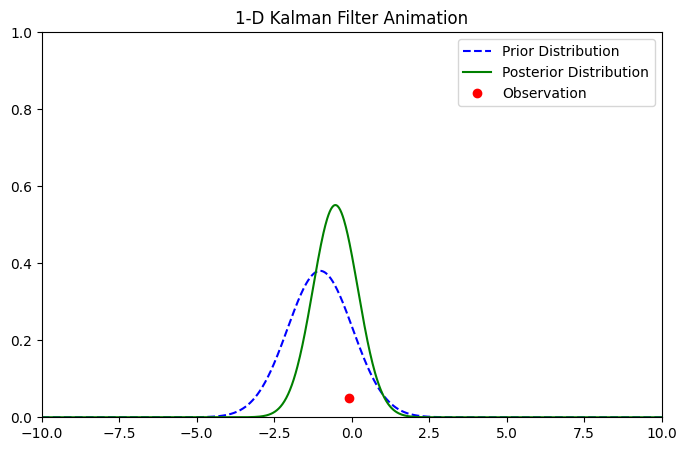

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm

# Parameters [cite: 50]
a, q, h, r = 1.0, 0.5, 1.0, 1.0
m_prev, P_prev = 0.0, 1.0
true_state = 0.0

fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-10, 10, 1000)
line_prior, = ax.plot([], [], 'b--', label='Prior Distribution')
line_post, = ax.plot([], [], 'g-', label='Posterior Distribution')
obs_point, = ax.plot([], [], 'ro', label='Observation')

ax.set_xlim(-10, 10)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("1-D Kalman Filter Animation")

def update(frame):
    global m_prev, P_prev, true_state

    # Simulate truth and observation
    true_state = a * true_state + np.random.normal(0, np.sqrt(q))
    y_obs = h * true_state + np.random.normal(0, np.sqrt(r))

    # Prediction (Prior)
    m_prior = a * m_prev
    P_prior = a**2 * P_prev + q

    # Update (Posterior)
    S = h**2 * P_prior + r
    K = (P_prior * h) / S
    m_post = m_prior + K * (y_obs - h * m_prior)
    P_post = (1 - K * h) * P_prior

    # Update plot lines
    line_prior.set_data(x_axis, norm.pdf(x_axis, m_prior, np.sqrt(P_prior)))
    line_post.set_data(x_axis, norm.pdf(x_axis, m_post, np.sqrt(P_post)))
    obs_point.set_data([y_obs], [0.05])

    m_prev, P_prev = m_post, P_post
    return line_prior, line_post, obs_point

ani = FuncAnimation(fig, update, frames=50, interval=500, blit=True)
plt.show()

# Q. 2D-Position Estimation Answer

Part A: State-Space Matrices


The state vector is defined as $x_{k}=[p_{x}(k), p_{y}(k), v_{x}(k), v_{y}(k)]^T$.  Matrix A: Using basic kinematics, position updates as $p = p_{prev} + v \Delta t$ and velocity remains constant (ignoring noise), so $v = v_{prev}$.$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$  Matrix G: Acceleration (process noise $w_k$) affects position by $\frac{1}{2}\Delta t^2$ and velocity by $\Delta t$.$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$  Matrix H: The measurement only captures the two position components.
  $$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$  
  
  
  
  Part B: Python filter for noisy GPS

In [3]:
import numpy as np

class KalmanFilter2D:
    def __init__(self, dt, std_acc, std_meas):
        self.dt = dt
        # Define Matrices
        self.A = np.array([[1, 0, dt, 0],
                           [0, 1, 0, dt],
                           [0, 0, 1, 0],
                           [0, 0, 0, 1]])
        self.G = np.array([[0.5 * dt**2, 0],
                           [0, 0.5 * dt**2],
                           [dt, 0],
                           [0, dt]])
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])

        # Process and Measurement Noise Covariances
        Sigma_p = np.eye(2) * std_acc**2
        self.Q = np.dot(np.dot(self.G, Sigma_p), self.G.T)
        self.R = np.eye(2) * std_meas**2

        # Initial State
        self.x = np.zeros((4, 1))
        self.P = np.eye(4)

    def predict(self):
        self.x = np.dot(self.A, self.x)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        return self.x[:2]

    def update(self, z):
        z = np.array(z).reshape((2, 1))
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))

        y_res = z - np.dot(self.H, self.x)
        self.x = self.x + np.dot(K, y_res)

        I = np.eye(self.H.shape[1])
        self.P = np.dot((I - np.dot(K, self.H)), self.P)
        return self.x[:2]

# Usage
kf = KalmanFilter2D(dt=1.0, std_acc=0.1, std_meas=2.0)
gps_measurements = [[1.1, 0.9], [2.2, 1.8], [3.0, 3.2], [4.5, 4.1]]

# Corrected Loop
filtered_path = []
for z in gps_measurements:
    kf.predict()  # Predict the next state
    est_pos = kf.update(z)  # Update with the current measurement
    filtered_path.append(est_pos.flatten().tolist())

print("Filtered Positions:", filtered_path)

Filtered Positions: [[0.36697209496043326, 0.3002498958767181], [1.3227301641557028, 1.0822337706728478], [2.4221863708578453, 2.356084924432172], [3.7899562287136384, 3.561760114953767]]
